In [2]:
import os
import sys; sys.path.append(os.path.abspath('..'))
from src.environment import WarehouseEnv
from src.utils.visualization import EnvironmentVisualizer, FunctionVisualizer, create_evaluation_animation
import yaml

with open("../config/warehouse_clf-cbf-rrt.yaml", 'r') as f:
    config = yaml.safe_load(f)
env = WarehouseEnv(config)



The original paper focused on linear systems and simple obstacles to guarantee tractable CLF-CBF compatibility checks. Applying it to the nonlinear unicycle model and mixed obstacles requires a few key modifications. 

1. Linearization: Linearizing the dynamics around current state x 
2. Higher order CBF. 

CBF-CLF-RRT Planning Loop
The RRT search tree $T$ is built in the 4D state space, but the core distinction is the Compatibility Check performed on every candidate edge.

Algorithm Steps
1. Initialize Tree $T$ with the start state $\mathbf{x}_{\text{init}}$.
2. Sample State: $\mathbf{x}_{\text{rand}} \leftarrow \text{RandomSample}()$.
3. Find Nearest Neighbor: $\mathbf{x}_{\text{near}} \leftarrow \text{NearestNeighbor}(T, \mathbf{x}_{\text{rand}})$.
4. Steer: $\mathbf{x}_{\text{new}} \leftarrow \text{Steer}(\mathbf{x}_{\text{near}}, \mathbf{x}_{\text{rand}}, \eta)$, generating a short, connecting segment.
5. Collision Check: If the segment is not $\text{collision-free}$ in $(x, y)$, discard the edge.
6. Compatibility Check (CRITICAL STEP): For the segment $\overline{\mathbf{x}_{\text{near}}\mathbf{x}_{\text{new}}}$, solve the Quadratic Program (QP).
7. Goal: Check if a control input $\mathbf{u}$ exists at every point on the segment that satisfies the combined CLF-CBF constraints.
8. If Feasible: Add $\mathbf{x}_{\text{new}}$ to $T$ and add the edge $\mathbf{x}_{\text{near}} \to \mathbf{x}_{\text{new}}$.
9. If Infeasible: Discard the edge.
10. Goal Check: If $\mathbf{x}_{\text{new}}$ is within the goal region, return the path by tracing back parents.

Core Feasibility Check: Quadratic Program (QP)

The compatibility check (Step 6) is implemented by checking the feasibility of a single-step control input $\mathbf{u}$ that satisfies three types of constraints simultaneously.

Optimization Problem (Solved at each step $\mathbf{x}_k$ along the segment)

$$\begin{aligned} \min_{\mathbf{u} \in \mathbb{R}^2} \quad & \| \mathbf{u} \|^2 \quad (\text{Minimize control effort}) \\ \text{s.t.} \quad & \mathbf{u}_{\text{min}} \le \mathbf{u} \le \mathbf{u}_{\text{max}} \quad (\text{Input Constraints}) \\ & L_g V(\mathbf{x}_k) \mathbf{u} \le -L_f V(\mathbf{x}_k) - \alpha_{\text{CLF}} V(\mathbf{x}_k) \quad (\text{CLF Constraint}) \\ & L_g L_f h_i(\mathbf{x}_k) \mathbf{u} \ge -L_f^2 h_i(\mathbf{x}_k) - \kappa(\dot{h}_i, h_i) \quad (\text{CBF Constraints}) \end{aligned}$$


CLF (Goal) - Ensures progress towards the target waypoint $\mathbf{x}_{\text{new}}$.

$\dot{V}(\mathbf{x}) \le -\alpha_{\text{CLF}} V(\mathbf{x})$

$L_f V(\mathbf{x})$, $L_g V(\mathbf{x})$

CBF (Safety) - Ensures the predicted acceleration $\ddot{h}$ keeps the robot safe from obstacle $i$.

$\ddot{h}_i(\mathbf{x}, \mathbf{u}) \ge -\kappa(\dot{h}_i, h_i)$

$L_f^2 h_i(\mathbf{x})$, $L_g L_f h_i(\mathbf{x})$

Input: Bounds the physical limits of the unicycle.

Feasibility Check: If the QP solver returns a solution (optimal or near-optimal status), the segment is compatible. If the QP solver returns infeasible (no $\mathbf{u}$ exists that satisfies all constraints), the segment is incompatible and is pruned.



In [3]:
# Import the C-CLF-CBF-RRT planner implementation
from src.baselines import CCLFCBFRRT
import numpy as np

# The implementation is now in src/baselines/clf_cbf_rrt_planner.py
# It includes:
# - UnicyclePlannerCore: Handles Lie derivative calculations and QP solving
# - CCLFCBFRRT: Main RRT planner that uses CLF-CBF compatibility checking

print("C-CLF-CBF-RRT planner imported successfully!")
print("\nKey components:")
print("- UnicyclePlannerCore: Computes CLF/CBF derivatives and solves QP")
print("- CCLFCBFRRT: RRT planner with CLF-CBF compatibility checking")
print("\nThe planner uses:")
print("- Relative Degree 2 CBF for obstacle avoidance")
print("- CLF for goal-reaching")
print("- QP solver (cvxpy) for compatibility checking at each RRT step")

C-CLF-CBF-RRT planner imported successfully!

Key components:
- UnicyclePlannerCore: Computes CLF/CBF derivatives and solves QP
- CCLFCBFRRT: RRT planner with CLF-CBF compatibility checking

The planner uses:
- Relative Degree 2 CBF for obstacle avoidance
- CLF for goal-reaching
- QP solver (cvxpy) for compatibility checking at each RRT step


(<Figure size 1400x1200 with 1 Axes>,
 <Axes: xlabel='X Position (meters)', ylabel='Y Position (meters)'>)

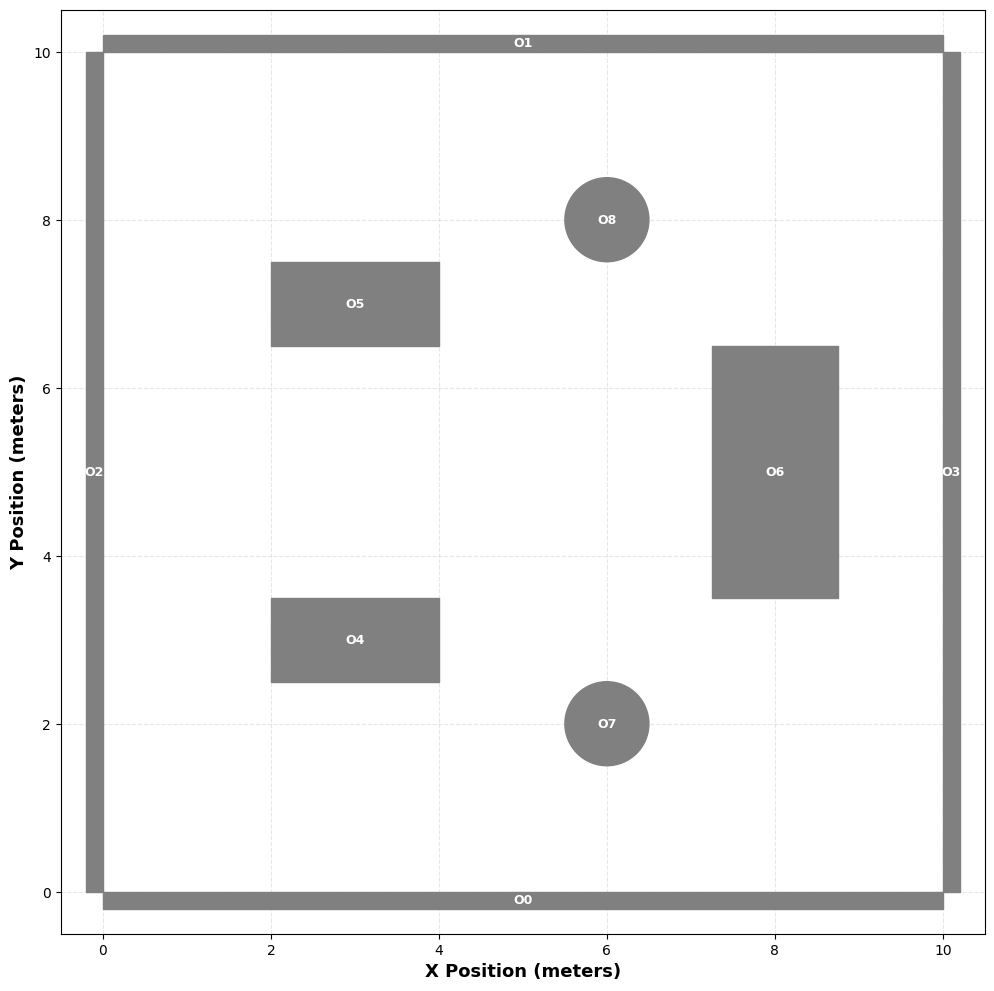

In [4]:
env = WarehouseEnv(config)
EnvironmentVisualizer(env).plot_environment()

This uses:
- Adaptive CLF constraint: Scales with distance to goal (less strict when far)
- Conditional CLF enforcement: Only enforces CLF when within 5m of goal; during exploration, only CBF constraints are checked
- Slack variables: Added to both CLF and CBF constraints to improve QP feasibility
- Debugging output: Added to show which checks pass/fail

Why it was failing:

When the robot is stopped (v=0) and far from the goal, the CLF constraint requires immediate progress, which can be infeasible. The constraint LgV * u <= -LfV - alpha_clf * V becomes very strict when V is large (far from goal) and v=0 (LfV=0).

The fix:
- During exploration (far from goal): Skip CLF constraint, only check CBF (safety)
- Near goal (<5m): Enforce CLF with adaptive alpha
- Always: Use slack variables to handle edge cases
This allows the tree to expand. The planner will focus on safety (CBF) during exploration and add goal-reaching (CLF) when close to the goal.


Planning from [1. 1.] to [4. 4.]
Running C-CLF-CBF-RRT planner...
Sampled random state: [1.78519576 9.92565241 2.94887817 0.        ]
Nearest neighbor: [1. 1. 0. 0.]
Steered: [1.05090404 1.57864778 0.19117502 0.        ]
  ✓ Collision check passed
  ✓ CLF-CBF compatibility check passed
Sampled random state: [0.33254037 3.85101241 0.82216828 0.        ]
Nearest neighbor: [1.05090404 1.57864778 0.19117502 0.        ]
Steered: [0.87471279 2.13598493 0.34593715 0.        ]
  ✓ Collision check passed
  ✓ CLF-CBF compatibility check passed
Sampled random state: [4.68262029 5.7410504  0.22965096 0.        ]
Nearest neighbor: [0.87471279 2.13598493 0.34593715 0.        ]
Steered: [1.30945886 2.54757267 0.33266084 0.        ]
  ✓ Collision check passed
  ✓ CLF-CBF compatibility check passed
Sampled random state: [9.39400095 5.77468927 2.69312242 0.        ]
Nearest neighbor: [1.30945886 2.54757267 0.33266084 0.        ]
Steered: [1.85199227 2.7641364  0.49106552 0.        ]
  ✗ Collision check 

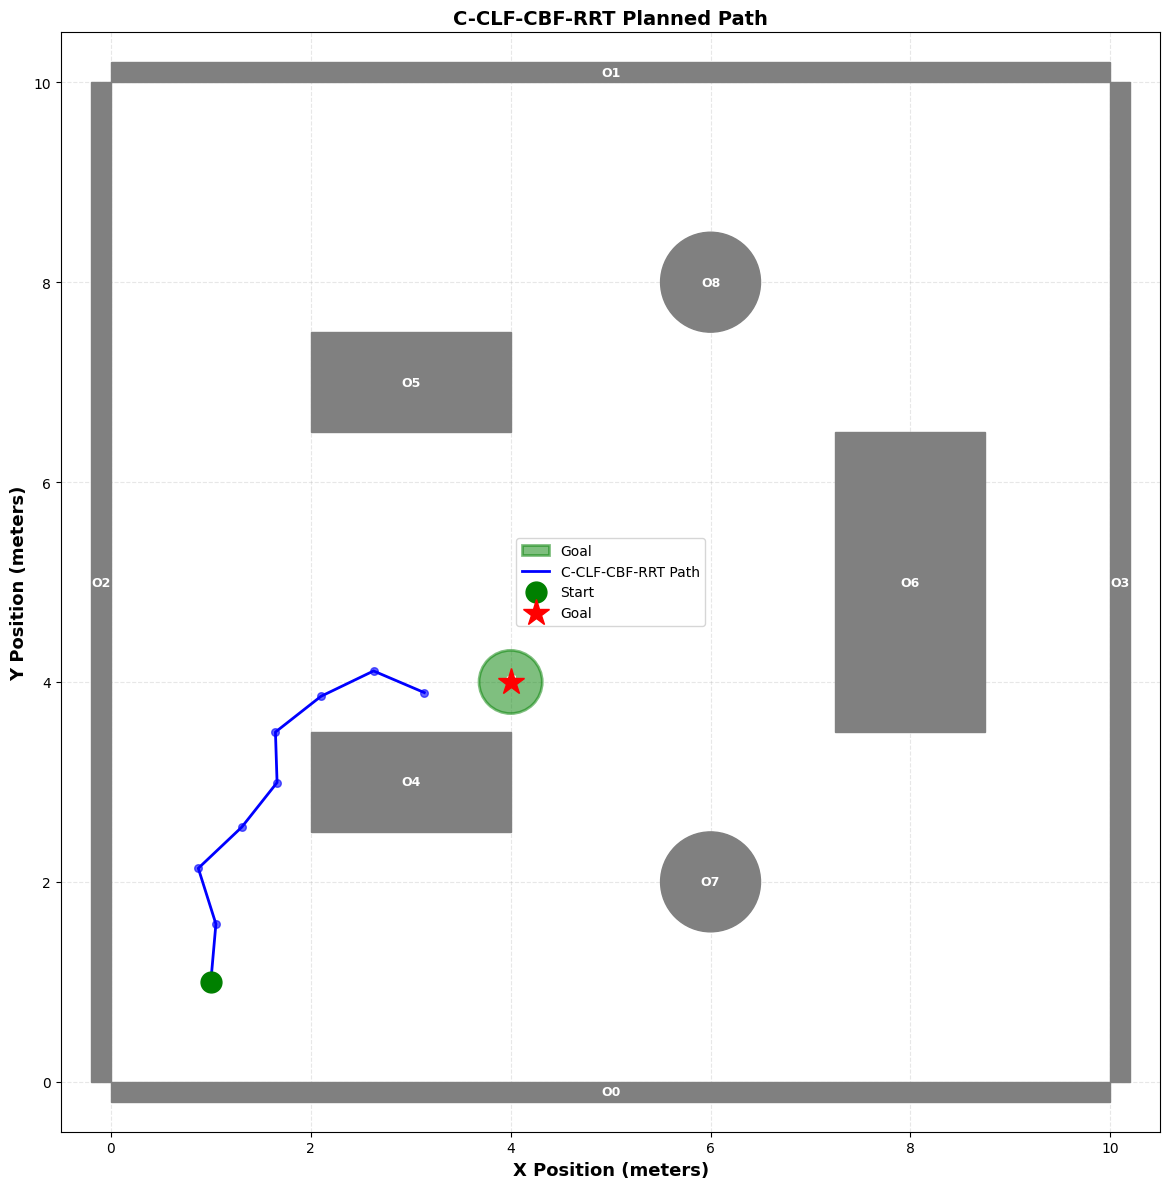

In [8]:
# Example: Plan a path using C-CLF-CBF-RRT
import matplotlib.pyplot as plt

# Initialize planner
planner = CCLFCBFRRT(
    env=env,
    config=config,
    max_iter=2000,  # Maximum RRT iterations
    step_size=0.6,   # Maximum step size for steering
    goal_tolerance=1  # Distance threshold for goal reaching
)

# Define start and goal states
# Start: [x, y, theta, v] - internal state format
x_init = np.array([1.0, 1.0, 0.0, 0.0])  # Start at (1, 1), facing right, stopped
x_goal = np.array([4.0, 4.0, 0.0, 0.0])  # Goal position (can be 2D or 4D)

print(f"Planning from {x_init[:2]} to {x_goal[:2]}")
print("Running C-CLF-CBF-RRT planner...")

# Plan path
path = planner.plan(x_init, x_goal)

if path is not None:
    print(f"\n✓ Path found! ({len(path)} waypoints)")
    print(f"  First waypoint: {path[0][:2]}")
    print(f"  Last waypoint: {path[-1][:2]}")
    
    # Visualize the path
    viz = EnvironmentVisualizer(env)
    fig, ax = viz.plot_environment(goal=x_goal)
    
    # Plot path
    path_array = np.array(path)
    ax.plot(path_array[:, 0], path_array[:, 1], 'b-', linewidth=2, label='C-CLF-CBF-RRT Path', zorder=3)
    ax.scatter(path_array[:, 0], path_array[:, 1], c='blue', s=30, zorder=4, alpha=0.6)
    
    # Plot start and goal
    ax.plot(x_init[0], x_init[1], 'go', markersize=15, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=20, label='Goal', zorder=5)
    
    ax.set_title("C-CLF-CBF-RRT Planned Path", fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
else:
    print("\n✗ Planning failed - no path found")
    print("  Try increasing max_iter or adjusting step_size/goal_tolerance")
